In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [3]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [4]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [5]:
# =============================================================
# 4. YOUR IMPLEMENTATION HERE (HELPER FUNCTIONS AND CONSTANTS)
# =============================================================
def check_epoch_accuracy(loader, model):
    num_correct = 0
    num_samples = 0

    model.eval()

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            scores = model(images)
            _, predictions = scores.max(1)
            num_correct += (predictions == labels).sum()
            num_samples += predictions.size(0)

    model.train()

    return float(num_correct) / num_samples

def plot_accuracies(train_accs, val_accs, model_name):
    epochs = range(1, len(train_accs) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_accs, 'b-o', label='Training Accuracy')
    plt.plot(epochs, val_accs, 'r-o', label='Validation Accuracy')
    plt.ylim(0.5, 1)
    plt.title(f'{model_name.upper()} MODEL TRAINING AND VALIDATION ACCURACIES')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'report/figs/{model_name}_accs.png')
    plt.show()

def plot_losses(losses, model_name):
    epochs = range(1, len(losses) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, losses, 'g-o', label='Average Loss')
    plt.ylim(0, 2)
    plt.title(f'{model_name.upper()} MODEL AVERAGE TRAINING LOSSES')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(f'report/figs/{model_name}_loss.png')
    plt.show()

In [6]:
# ================================================
# 4. YOUR IMPLEMENTATION HERE (THE PANCAKE)
# ================================================

class PancakeMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(PancakeMLP, self).__init__()
        
        self.fc1 = nn.Linear(input_size, 1024)
        self.fc2 = nn.Linear(1024, 2048)
        self.fc3 = nn.Linear(2048, num_classes)

    def forward(self, x):
        x = x.view(-1, 784)

        x = self.fc1(x)
        x = nn.functional.relu(x)

        x = self.fc2(x)
        x = nn.functional.relu(x)

        x = self.fc3(x)
        return x
    
pancake_model = PancakeMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pancake_model.parameters(), lr=0.001)

pc_losses = []
pc_training_accs = []
pc_validation_accs = []

for epoch in range(EPOCHS):
    pancake_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = pancake_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    training_acc = check_epoch_accuracy(train_loader, pancake_model)
    validation_acc = check_epoch_accuracy(val_loader, pancake_model)
    average_loss = running_loss / len(train_loader)

    pc_losses.append(average_loss)
    pc_training_accs.append(training_acc)
    pc_validation_accs.append(validation_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {average_loss:.4f} | Train Acc: {training_acc:.4f} | Val Acc: {validation_acc:.4f}")

Epoch [1/40] | Loss: 1.0963 | Train Acc: 0.7254 | Val Acc: 0.6903
Epoch [2/40] | Loss: 0.7753 | Train Acc: 0.7891 | Val Acc: 0.7403
Epoch [3/40] | Loss: 0.6300 | Train Acc: 0.8307 | Val Acc: 0.7582
Epoch [4/40] | Loss: 0.5197 | Train Acc: 0.8670 | Val Acc: 0.7613
Epoch [5/40] | Loss: 0.4247 | Train Acc: 0.8765 | Val Acc: 0.7534
Epoch [6/40] | Loss: 0.3469 | Train Acc: 0.9091 | Val Acc: 0.7592
Epoch [7/40] | Loss: 0.2686 | Train Acc: 0.9343 | Val Acc: 0.7618
Epoch [8/40] | Loss: 0.2171 | Train Acc: 0.9504 | Val Acc: 0.7574
Epoch [9/40] | Loss: 0.1714 | Train Acc: 0.9571 | Val Acc: 0.7547
Epoch [10/40] | Loss: 0.1354 | Train Acc: 0.9662 | Val Acc: 0.7489
Epoch [11/40] | Loss: 0.1010 | Train Acc: 0.9753 | Val Acc: 0.7610
Epoch [12/40] | Loss: 0.0909 | Train Acc: 0.9768 | Val Acc: 0.7558
Epoch [13/40] | Loss: 0.0791 | Train Acc: 0.9759 | Val Acc: 0.7523
Epoch [14/40] | Loss: 0.0731 | Train Acc: 0.9796 | Val Acc: 0.7568
Epoch [15/40] | Loss: 0.0704 | Train Acc: 0.9830 | Val Acc: 0.7536
Epoc

In [7]:
# ================================================
# 4. YOUR IMPLEMENTATION HERE (THE TOWER)
# ================================================

class TowerMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(TowerMLP, self).__init__()
        
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 256)
        self.fc3 = nn.Linear(256, 512)
        self.fc4 = nn.Linear(512, 256)
        self.fc5 = nn.Linear(256, 128)
        self.fc6 = nn.Linear(128, num_classes)

        self.bn1 = nn.BatchNorm1d(128)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(512)
        self.bn4 = nn.BatchNorm1d(256)
        self.bn5 = nn.BatchNorm1d(128)

    def forward(self, x):
        x = x.view(-1, 784)

        x = self.fc1(x)
        x = self.bn1(x)
        x = nn.functional.relu(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = nn.functional.relu(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = nn.functional.relu(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = nn.functional.relu(x)

        x = self.fc5(x)
        x = self.bn5(x)
        x = nn.functional.relu(x)

        x = self.fc6(x)
        return x
    
tower_model = TowerMLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(tower_model.parameters(), lr=0.001)

tw_losses = []
tw_training_accs = []
tw_validation_accs = []

for epoch in range(EPOCHS):
    tower_model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = tower_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    training_acc = check_epoch_accuracy(train_loader, tower_model)
    validation_acc = check_epoch_accuracy(val_loader, tower_model)
    average_loss = running_loss / len(train_loader)

    tw_losses.append(average_loss)
    tw_training_accs.append(training_acc)
    tw_validation_accs.append(validation_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {average_loss:.4f} | Train Acc: {training_acc:.4f} | Val Acc: {validation_acc:.4f}")

Epoch [1/40] | Loss: 1.0483 | Train Acc: 0.7503 | Val Acc: 0.7184
Epoch [2/40] | Loss: 0.7844 | Train Acc: 0.7818 | Val Acc: 0.7356
Epoch [3/40] | Loss: 0.6846 | Train Acc: 0.8157 | Val Acc: 0.7493
Epoch [4/40] | Loss: 0.6110 | Train Acc: 0.8367 | Val Acc: 0.7588
Epoch [5/40] | Loss: 0.5552 | Train Acc: 0.8552 | Val Acc: 0.7540
Epoch [6/40] | Loss: 0.5033 | Train Acc: 0.8670 | Val Acc: 0.7598
Epoch [7/40] | Loss: 0.4587 | Train Acc: 0.8818 | Val Acc: 0.7541
Epoch [8/40] | Loss: 0.4194 | Train Acc: 0.8921 | Val Acc: 0.7576
Epoch [9/40] | Loss: 0.3828 | Train Acc: 0.9070 | Val Acc: 0.7596
Epoch [10/40] | Loss: 0.3454 | Train Acc: 0.9153 | Val Acc: 0.7602
Epoch [11/40] | Loss: 0.3178 | Train Acc: 0.9309 | Val Acc: 0.7567
Epoch [12/40] | Loss: 0.2979 | Train Acc: 0.9390 | Val Acc: 0.7565
Epoch [13/40] | Loss: 0.2541 | Train Acc: 0.9384 | Val Acc: 0.7516
Epoch [14/40] | Loss: 0.2419 | Train Acc: 0.9487 | Val Acc: 0.7450
Epoch [15/40] | Loss: 0.2139 | Train Acc: 0.9538 | Val Acc: 0.7522
Epoc

In [ ]:
# ================================================
# 4. YOUR IMPLEMENTATION HERE (THE CHAMPION)
# ================================================
CHAMPION_EPOCHS = 40
class ChampionMLP(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(ChampionMLP, self).__init__()
        
        # self.fc1 = nn.Linear(input_size, 100)
        # self.fc2 = nn.Linear(100, 50)
        # self.fc3 = nn.Linear(50, 40)
        # self.fc4 = nn.Linear(40, 30)
        # self.fc5 = nn.Linear(30, num_classes)

        self.fc1 = nn.Linear(input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, num_classes)

        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)
        # self.bn4 = nn.BatchNorm1d(30)

        self.do1 = nn.Dropout(0.3)
        self.do2 = nn.Dropout(0.2)
        self.do3 = nn.Dropout(0.1)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        x = x.view(-1, 784)

        x = self.fc1(x)  
        x = self.bn1(x)
        x = nn.functional.gelu(x)
        x = self.do1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = nn.functional.gelu(x)
        x = self.do2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = nn.functional.gelu(x)
        x = self.do3(x)

        x = self.fc4(x)
        # x = self.bn4(x)
        # x = nn.functional.gelu(x)
        # x = self.dropout_late(x)

        # x = self.fc5(x)S
        return x
    
model = ChampionMLP()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.002)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.002, steps_per_epoch=len(train_loader), epochs=CHAMPION_EPOCHS, pct_start=0.4, anneal_strategy='cos')

ch_losses = []
ch_training_accs = []
ch_validation_accs = []

best_val_acc = 0.0
trigger_count = 0

for epoch in range(CHAMPION_EPOCHS):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        l1_lambda = 8e-5
        l1_penalty = 0
        for name, param in model.named_parameters():
            if 'weight' in name and 'bn' not in name:
                l1_penalty += torch.norm(param, 1)

        loss = loss + (l1_lambda * l1_penalty)
        
        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

    training_acc = check_epoch_accuracy(train_loader, model)
    validation_acc = check_epoch_accuracy(val_loader, model)
    average_loss = running_loss / len(train_loader)

    ch_losses.append(average_loss)
    ch_training_accs.append(training_acc)
    ch_validation_accs.append(validation_acc)

    print(f"Epoch [{epoch+1}/{CHAMPION_EPOCHS}] | Loss: {average_loss:.4f} | Train Acc: {training_acc:.4f} | Val Acc: {validation_acc:.4f}")

    if validation_acc > best_val_acc:
        best_val_acc = validation_acc
        trigger_count = 0
        torch.save(model.state_dict(), "champion_model.pth")
        print("Model saved successfully as 'champion_model.pth'")
    else:
        trigger_count += 1

    if trigger_count >= 5:
        print(f"Early stopping triggered at epoch {epoch+1}. Generalization peaked.")
        break

Epoch [1/40] | Loss: 3.6113 | Train Acc: 0.6049 | Val Acc: 0.5913
Model saved successfully as 'champion_model.pth'
Epoch [2/40] | Loss: 2.9967 | Train Acc: 0.6751 | Val Acc: 0.6563
Model saved successfully as 'champion_model.pth'
Epoch [3/40] | Loss: 2.7475 | Train Acc: 0.7191 | Val Acc: 0.6929
Model saved successfully as 'champion_model.pth'
Epoch [4/40] | Loss: 2.5310 | Train Acc: 0.7495 | Val Acc: 0.7151
Model saved successfully as 'champion_model.pth'
Epoch [5/40] | Loss: 2.3138 | Train Acc: 0.7682 | Val Acc: 0.7277
Model saved successfully as 'champion_model.pth'
Epoch [6/40] | Loss: 2.1127 | Train Acc: 0.7857 | Val Acc: 0.7418
Model saved successfully as 'champion_model.pth'
Epoch [7/40] | Loss: 1.9501 | Train Acc: 0.7912 | Val Acc: 0.7407
Epoch [8/40] | Loss: 1.8340 | Train Acc: 0.7910 | Val Acc: 0.7474
Model saved successfully as 'champion_model.pth'
Epoch [9/40] | Loss: 1.7754 | Train Acc: 0.7926 | Val Acc: 0.7463
Epoch [10/40] | Loss: 1.7395 | Train Acc: 0.7840 | Val Acc: 0.7

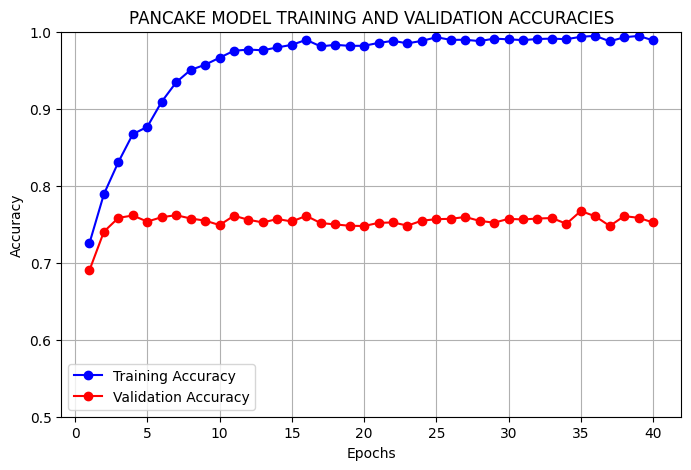

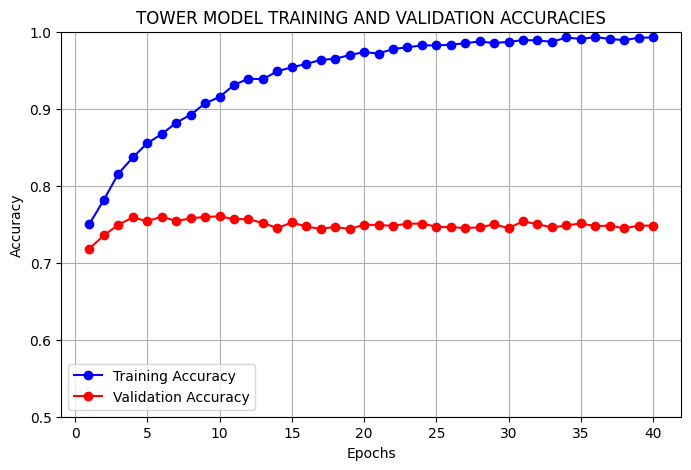

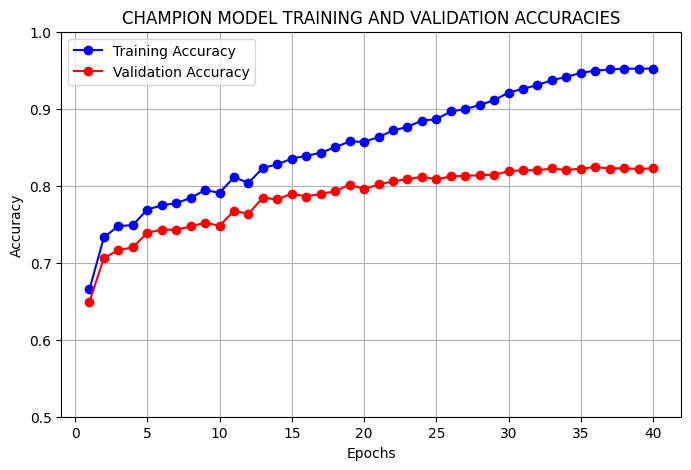

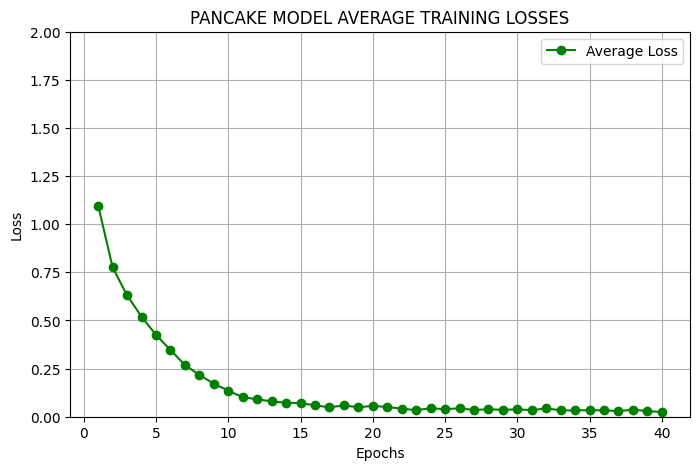

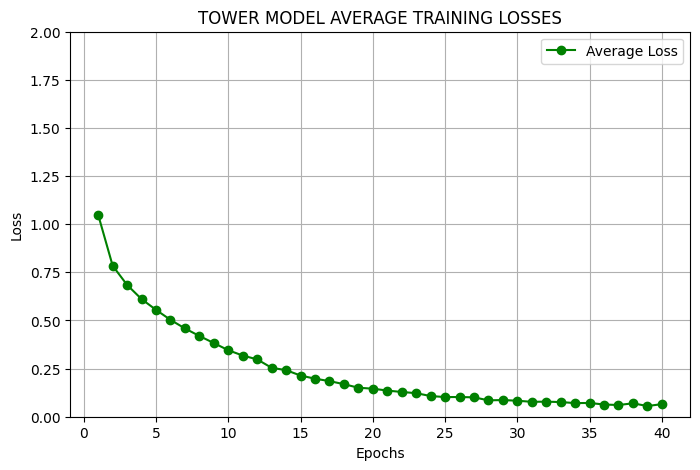

The pancake model has 2933775 parameters
The tower model has 433807 parameters


In [61]:
# ================================================
# 4. YOUR IMPLEMENTATION HERE (THE PLOTS)
# ================================================

plot_accuracies(pc_training_accs, pc_validation_accs, 'pancake')
plot_accuracies(tw_training_accs, tw_validation_accs, 'tower')
plot_accuracies(ch_training_accs, ch_validation_accs, 'champion')

plot_losses(pc_losses, 'pancake')
plot_losses(tw_losses, 'tower')

print(f'The pancake model has {sum(p.numel() for p in pancake_model.parameters() if p.requires_grad)} parameters')
print(f'The tower model has {sum(p.numel() for p in tower_model.parameters() if p.requires_grad)} parameters')

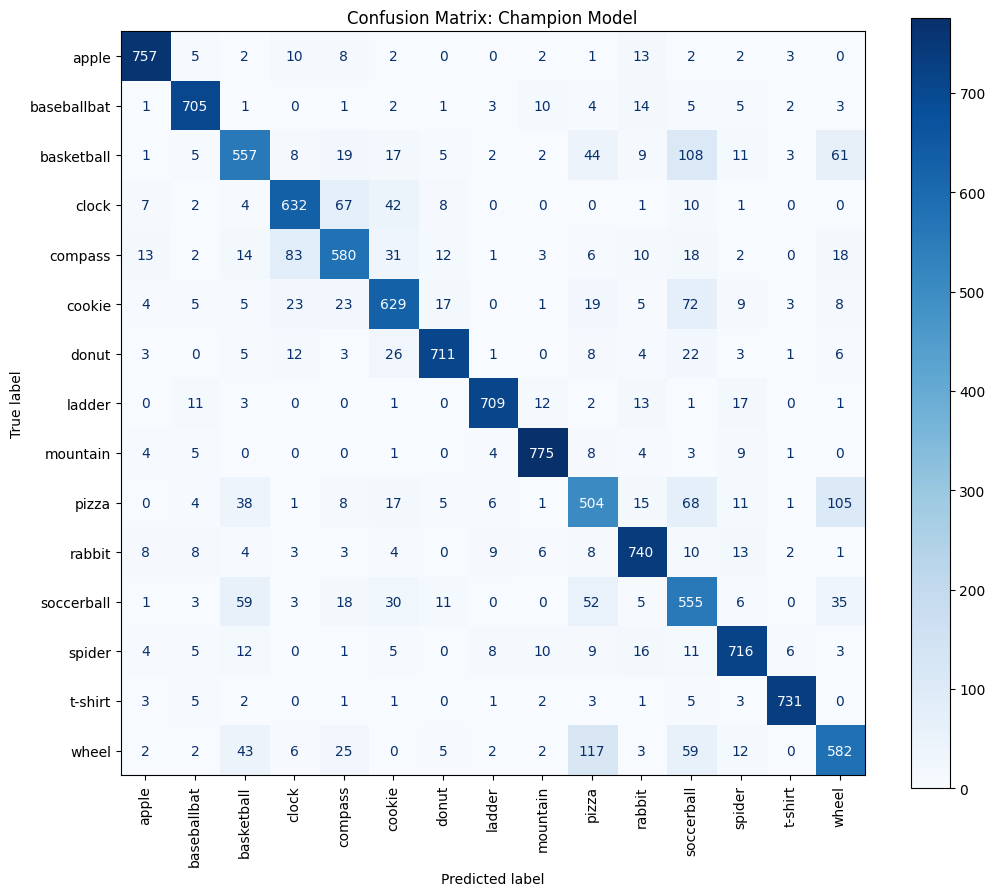

In [48]:
# ===================================================
# 4. YOUR IMPLEMENTATION HERE (THE CONFUSION MATRIX)
# ===================================================

model = ChampionMLP().to(DEVICE)
model.load_state_dict(torch.load('champion_model.pth', map_location=DEVICE))

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Create the Matrix
cm = confusion_matrix(all_labels, all_preds)

# 4. Plot
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title("Confusion Matrix: Champion Model")
plt.savefig('report/figs/conf-matrix.png')
plt.show()

In [51]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [50]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 569,871
  ✅ Parameter count is within limits.
